<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Entropy: bias-corrected estimators (Miller-Madow, Grassberger, NSB)
    </h1>
  </div>
</div>

The **plug-in / maximum-likelihood** entropy (AFML ch.18) underestimates
entropy when the alphabet (number of possible words) is large relative to the
sample, because unobserved symbols contribute zero. The bias is about
`-(K-1)/(2N)`. Three corrections add the missing mass back: **Miller-Madow**
(first order), **Grassberger** (higher order), and **NSB** (Bayesian, needs the
true alphabet size).

*Baseline (plug-in) -> where it breaks (undersampling) -> corrections -> when to use.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Features: plug_in_entropy_estimator, miller_madow_entropy,
    grassberger_entropy, nsb_entropy

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. A known-entropy source, undersampled
We draw i.i.d. symbols from a 4-letter alphabet and encode words of length 3
(effective alphabet `4^3 = 64`). The true per-symbol entropy is `log2(4) = 2`
bits. We watch each estimator as the sample `N` grows from deeply undersampled.

In [2]:
truth = 2.0                              # log2(4) bits/symbol, uniform 4-letter source
alphabet = ['a', 'b', 'c', 'd']
word = 3
rng = MersenneTwister(1)
Ns = [60, 120, 250, 500, 1000, 2500, 6000]
plugin = Float64[]; mm = Float64[]; gr_ = Float64[]; nsb = Float64[]
for N in Ns
    msg = String(rand(rng, alphabet, N))
    push!(plugin, plug_in_entropy_estimator(msg, word))
    push!(mm, miller_madow_entropy(msg, word))
    push!(gr_, grassberger_entropy(msg, word))
    push!(nsb, nsb_entropy(msg, word, 4))      # true base alphabet = 4
end
println("N=60   plug-in=", round(plugin[1], digits=3), "  NSB=", round(nsb[1], digits=3))
println("N=6000 plug-in=", round(plugin[end], digits=3), "  NSB=", round(nsb[end], digits=3))

N=60   plug-in=1.726  NSB=1.947
N=6000 plug-in=1.997  NSB=1.995


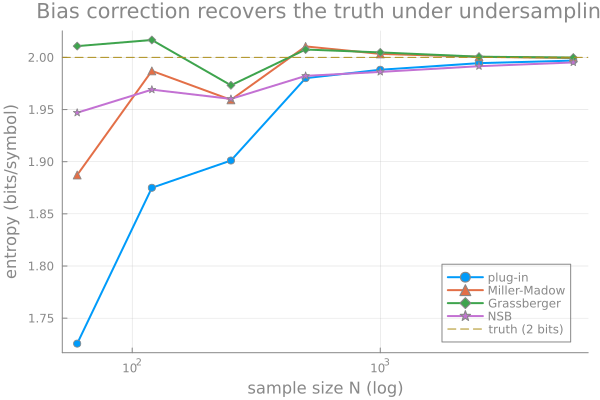

In [3]:
plot(Ns, plugin; label = "plug-in", lw = 2, marker = :circle, xscale = :log10,
     xlabel = "sample size N (log)", ylabel = "entropy (bits/symbol)",
     title = "Bias correction recovers the truth under undersampling")
plot!(Ns, mm; label = "Miller-Madow", lw = 2, marker = :utriangle)
plot!(Ns, gr_; label = "Grassberger", lw = 2, marker = :diamond)
plot!(Ns, nsb; label = "NSB", lw = 2, marker = :star5)
hline!([truth]; label = "truth (2 bits)", ls = :dash)

## When to use / when NOT (from `appraisals/06_verdict.md`)
**Prefer a bias-corrected estimator over the plug-in whenever the symbol counts
are undersampled** (a large effective alphabet relative to the sample: long
words, fine encodings, or short windows). **NSB is most accurate in deep
undersampling; Grassberger is close at lower cost** (the practical default when
undersampled); **Miller-Madow is the cheap first-order fix.** All converge to the
plug-in when `N >> K` with no over-correction, so a correction is a safe default.
The gain is negligible for coarse encodings (e.g. binary), and a gap caused by
non-stationarity is not an entropy-bias problem the correction can fix.